In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

projection_method = "MDS"

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["acsf"])
df = qm9.load()
X=np.array(df["acsf_embedding"].to_list())

2026-05-09 11:45:17.782 | INFO     | src.datasets:_load_full_qm9_df:813 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-09 11:45:18.320 | INFO     | src.datasets:_sample_qm9_df:996 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-05-09 11:45:18.321 | INFO     | src.datasets:_add_requested_descriptors:198 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-09 11:45:18.329 | INFO     | src.features:compute_acsf_outputs:537 - Computing ACSF (rcut=6.0, normalize=True)...
2026-05-09 11:45:22.194 | SUCCESS  | src.datasets:add_acsf:1199 - Added ACSF embeddings and matrices.
2026-05-09 11:45:22.196 | INFO     | src.datasets:_add_requested_descriptors:209 - Added descriptor column(s): ['acsf_embedding', 'acsf_matrix']
2026-05-09 11:45:22.199 | INFO     | src.datasets:_load_with_descriptor_filter:853 - QM9 descriptor null-filtering complete: attempts=1, requested_limit=5000, returned_rows=5000

In [4]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="acsf",
    dist_type="euclidean",
    pca_components=4,
)

2026-05-09 11:45:22.269 | INFO     | src.datasets:get_distance_matrix:1296 - Applying PCA to reduce 'acsf' to 4 dimensions.
2026-05-09 11:45:22.284 | INFO     | src.datasets:get_distance_matrix:1300 - PCA kept 95.32% of the variance for 'acsf'.
2026-05-09 11:45:22.285 | INFO     | src.datasets:get_distance_matrix:1302 - PCA reduced 'acsf' dimensions from 65 to 4
2026-05-09 11:45:22.304 | INFO     | src.datasets:get_distance_matrix:1313 - Calculating distance matrix for acsf using euclidean distance.


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:11<00:00,  1.19s/it]


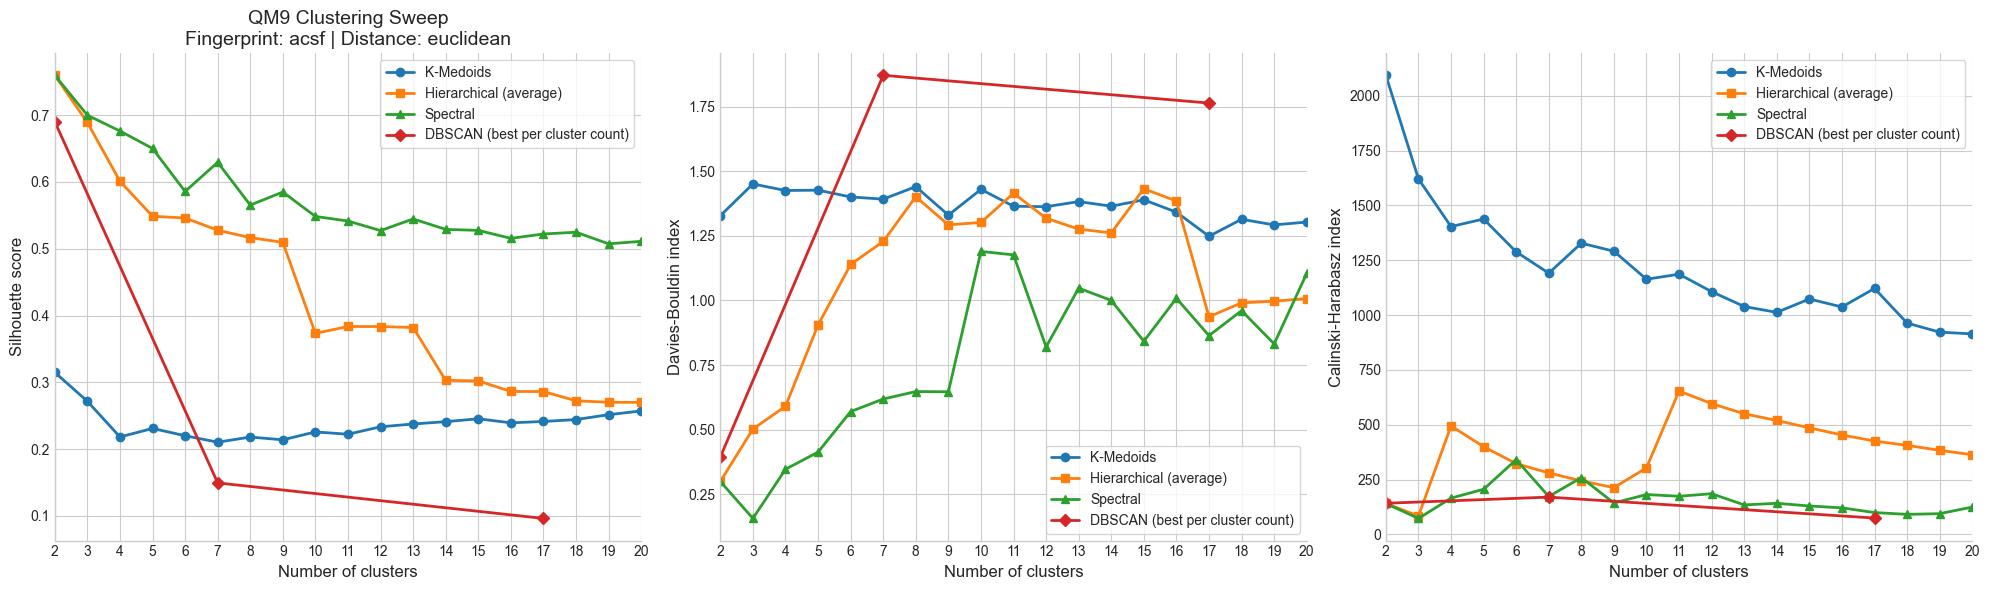

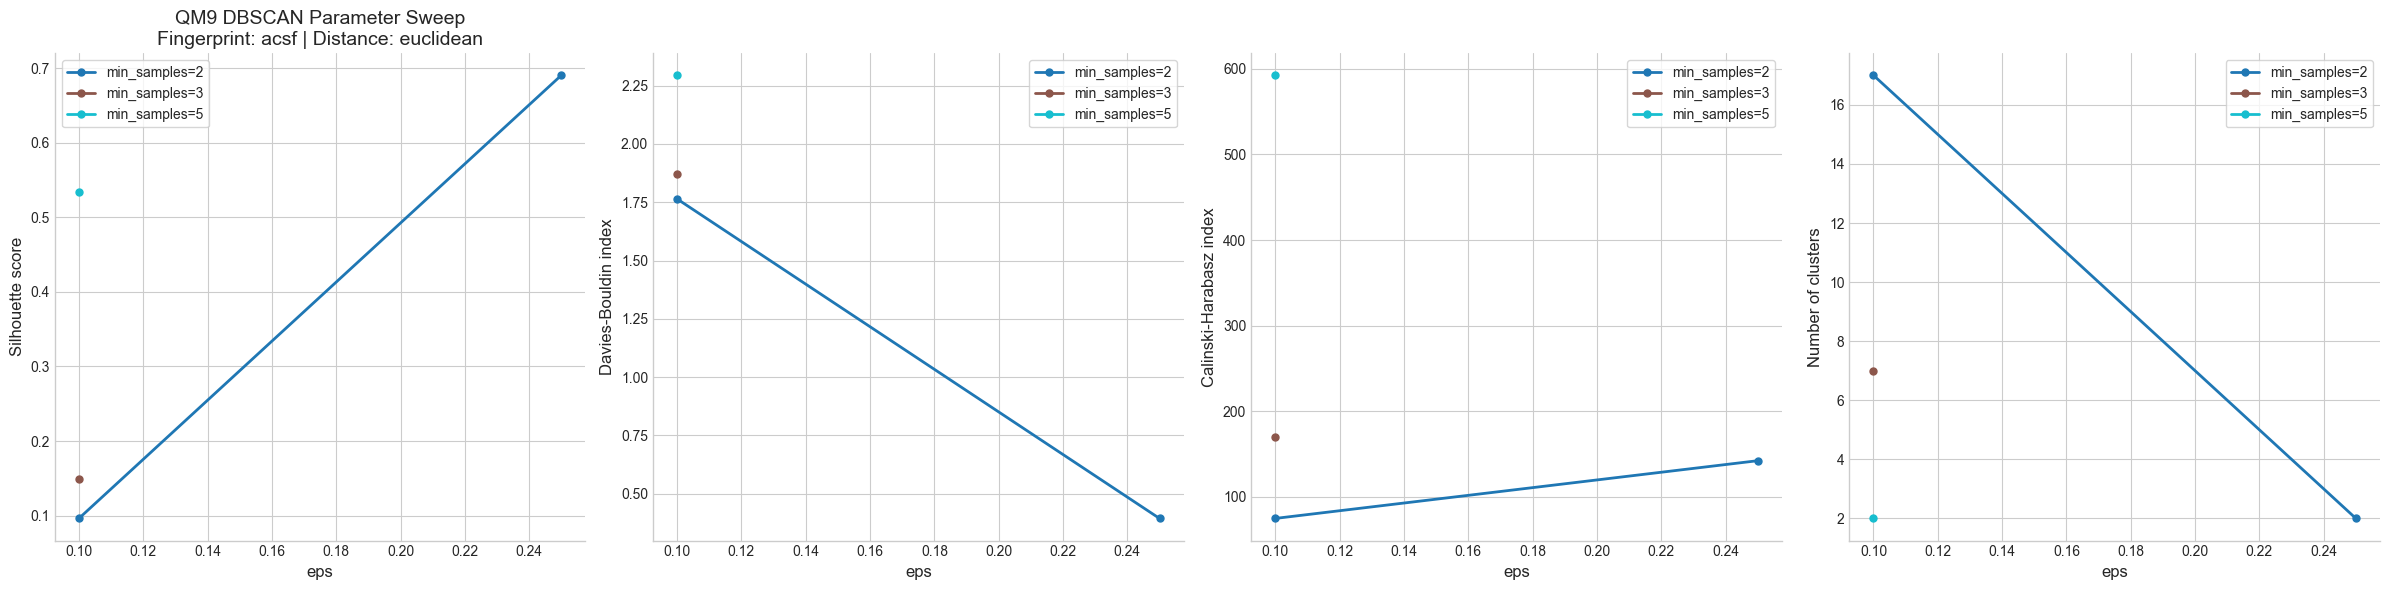

2026-05-09 11:46:57.879 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1060 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/acsf/clustering_sweep_2_to_20_clusters.png
2026-05-09 11:46:57.879 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1062 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/acsf/dbscan_parameter_sweep.png
2026-05-09 11:46:57.880 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1063 - Saved clustering sweep results to figures/qm9/clustering/euclidean/acsf/clustering_sweep_2_to_20_clusters.json


In [5]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    dataset_name="qm9",
)

# Hiercical Clustering on Distance Matrix

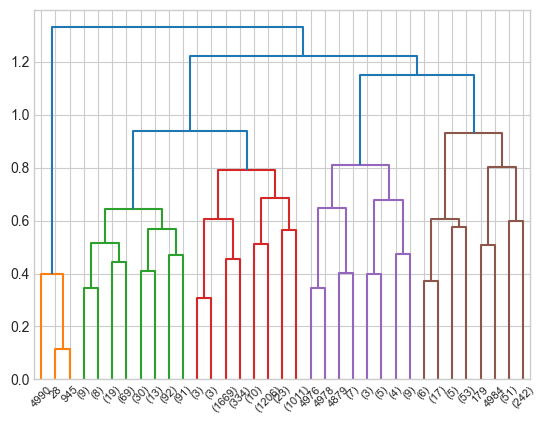

In [6]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=5                
)

In [7]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)

In [42]:
create_chemiscope_viewer(df, X, labels_hier, 'PCA')

2026-05-12 10:48:30.015 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-12 10:48:30.018 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-12 10:49:16.882 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-12 10:49:16.954 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-12 10:49:17.211 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-12 10:49:17.301 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


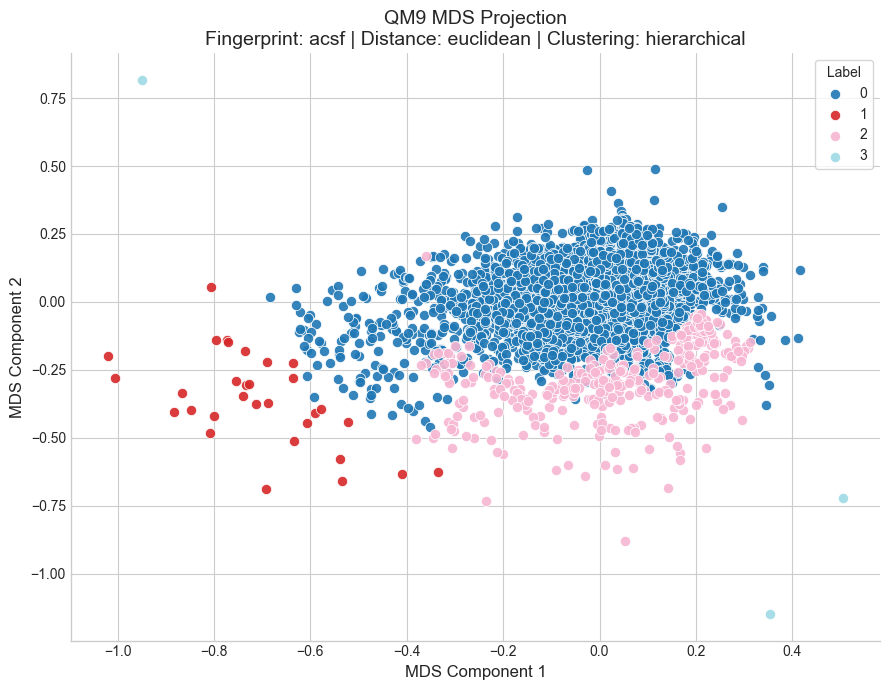

2026-05-12 20:50:56.133 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/euclidean/acsf/mds_hierarchical_projection.png


In [61]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method='MDS',
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [10]:
average_numeric_by_cluster(df, "labels_hier")

shape: (4, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬──────────┬─────────┬─────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4590,0.745808,0.0,122.57342,0.123094,35.223312,0.858299,12.851721,8.770588,1.679303,0.153595,0.017211,2.34488,18.659695,2.061918,2.376035,0.061047,0.206917,0.732036,0.925708,1.931808,6.624619,0.405664,1.194989,4.825054,6.374074,13.708279,1.26135,0.002614,0.356209,0.027451,0.132026,0.116993,0.002179,0.032462,0.114597,0.494118,0.001307,2.664982,75.911233,-6.508165,0.427582,6.935751,1198.072819,4.172939,-11071.327604,-11071.094457,-11071.068757,-11072.239246,31.966606,-77.250661,-77.726025,-78.172819,-71.875911,3.54656,1.475034,1.196713,74.335512,14.858388,10.8061,13.708279,1425,"""Acyclic""",10.8061,296,"""C1CCCC1""",12.265795,1,null,0.0
1,31,1.094703,0.0,112.870968,-0.387097,74.774194,0.091521,13.457856,8.096774,1.16129,1.064516,0.225806,5.387097,10.290323,2.020554,0.483871,0.152151,0.78871,0.05914,0.774194,4.322581,3.129032,0.548387,2.032258,0.129032,5.258065,11.129032,1.284982,0.0,0.0,0.096774,0.193548,0.0,0.0,0.0,0.0,0.0,0.0,3.535323,56.91387,-7.633935,-2.255385,5.37855,852.093939,1.675825,-11590.875473,-11590.705881,-11590.680302,-11591.704432,22.172032,-44.810077,-45.029805,-45.263528,-41.785859,5.157287,2.220297,1.568701,9.677419,87.096774,3.225806,11.129032,25,"""c1nnon1""",9.677419,9,"""C1CCCCC1""",29.032258,1,null,0.0
2,376,0.960908,0.0,122.452128,-0.180851,51.893617,0.919395,12.832891,8.739362,1.468085,0.361702,0.114362,3.521277,13.976064,2.048998,1.444149,0.113298,0.472264,0.414438,0.718085,3.047872,4.949468,0.635638,2.340426,2.242021,5.952128,13.303191,1.278461,0.0,0.287234,0.101064,0.095745,0.106383,0.0,0.162234,0.255319,0.800532,0.005319,3.083318,65.71992,-6.902233,-1.106005,5.796163,1070.510099,2.70107,-12192.725143,-12192.517904,-12192.492224,-12193.612703,27.669604,-62.123016,-62.446239,-62.774227,-58.054116,3.851094,1.529464,1.15771,53.989362,34.042553,11.968085,13.303191,200,"""Acyclic""",11.968085,83,"""C1CCCC1""",17.021277,1,null,0.0
3,3,1.781818,0.0,126.0,1.666667,0.0,2.725444,15.706429,7.333333,0.0,0.0,5.333333,5.333333,8.0,1.722727,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,2.0,3.0,14.0,1.374921,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.580033,26.993334,-10.830131,3.359699,14.188924,686.725606,0.949859,-16574.620117,-16574.451172,-16574.425781,-16575.464518,21.166667,-33.899503,-34.039142,-34.218965,-31.609131,3.81942,2.875563,2.870027,0.0,0.0,100.0,14.0,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0


# KMedoids

In [48]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)
print(np.unique(labels_km, return_counts=True))

(array([0, 1, 2], dtype=uint64), array([1654, 2366,  980]))


In [12]:
create_chemiscope_viewer(df, X, labels_km, 'PCA')

2026-05-09 11:47:57.767 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-09 11:47:57.768 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-09 11:48:54.312 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-09 11:48:54.333 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-09 11:48:54.644 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-09 11:48:54.734 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

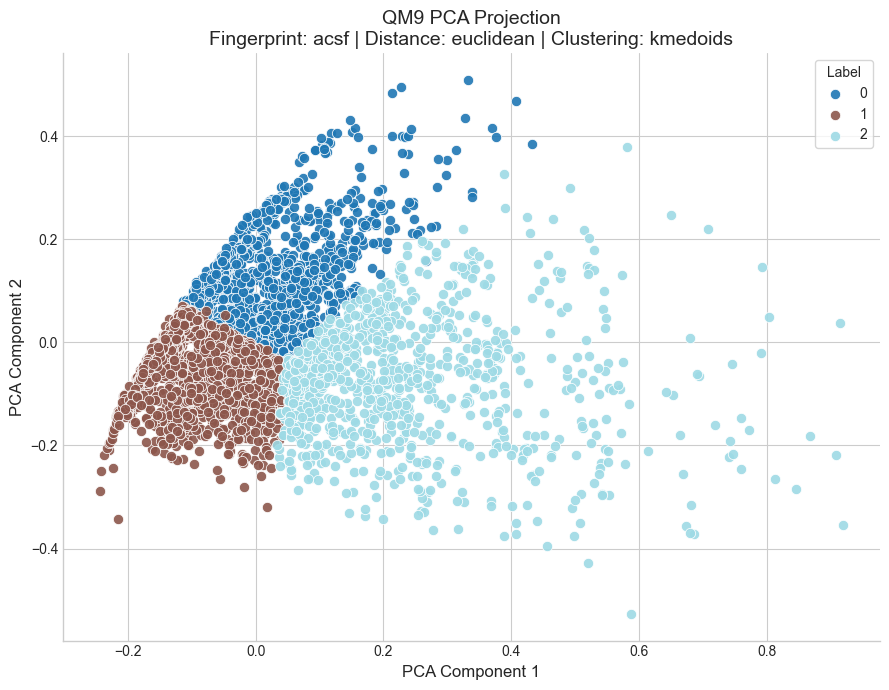

2026-05-12 10:52:19.361 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_kmedoids_projection.png


In [49]:
_=plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method='PCA',
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [14]:
average_numeric_by_cluster(df, "labels_km")

shape: (6, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1090,0.62051,0.0,123.472477,0.429358,28.715596,0.919326,12.876972,8.679817,1.125688,0.002752,0.005505,1.876147,21.348624,2.007068,3.888991,0.027271,0.068108,0.904621,0.877982,1.622936,6.926606,0.189908,0.43578,6.177982,6.744954,13.217431,1.24703,0.0,0.569725,0.0,0.06055,0.099083,0.005505,0.021101,0.065138,0.555046,0.0,2.264151,79.525872,-6.679863,1.178243,7.858119,1369.297076,5.044537,-10854.610176,-10854.347507,-10854.321803,-10855.557087,35.541593,-85.602763,-86.15623,-86.674841,-79.469684,3.752105,1.437396,1.219275,0.0,77.431193,0.275229,22.293578,13.217431,193,"""Acyclic""",22.293578,48,"""Acyclic""",22.293578,1,null,0.0
1,983,0.751636,0.0,122.479145,-0.29705,37.145473,0.758819,12.904671,8.816887,1.894201,0.19532,0.018311,2.537131,18.710071,2.079024,2.041709,0.067115,0.213644,0.719241,1.295015,1.785351,7.080366,0.431333,1.288911,4.559512,6.331638,13.994914,1.260058,0.002035,0.155646,0.028484,0.200407,0.203459,0.003052,0.008138,0.083418,0.197355,0.0,3.013811,76.690336,-6.248662,0.421115,6.669757,1171.631199,4.108416,-10912.346085,-10912.116539,-10912.090835,-10913.253567,31.55395,-76.321714,-76.791835,-77.232745,-71.000487,3.321994,1.406824,1.120592,0.0,74.059003,19.532045,6.408952,13.994914,464,"""Acyclic""",6.408952,145,"""C1CCCC1""",14.242116,1,null,0.0
2,734,0.914418,0.0,121.160763,-0.050409,37.686649,0.945666,12.726831,8.811989,1.985014,0.219346,0.085831,2.546322,15.385559,2.102161,1.119891,0.146726,0.315447,0.537827,0.63079,2.151226,5.694823,0.946866,1.896458,3.422343,5.980926,13.948229,1.279998,0.008174,0.242507,0.046322,0.073569,0.085831,0.0,0.085831,0.237057,0.594005,0.0,2.962691,70.980286,-6.705575,-0.514584,6.190957,1080.148203,3.130222,-11419.600144,-11419.391859,-11419.366188,-11420.484469,28.630832,-67.807134,-68.181965,-68.545047,-63.342944,3.485787,1.560425,1.245668,0.521798,68.80109,21.525886,9.673025,13.948229,381,"""Acyclic""",9.673025,152,"""C1CCCC1""",10.354223,1,null,0.0
3,814,0.748595,0.0,121.062654,0.739558,18.469287,0.968774,12.697574,8.829238,2.31941,0.019656,0.017199,1.20516,19.481572,2.115632,1.560197,0.06491,0.136919,0.79817,0.384521,1.121622,7.202703,0.504914,1.039312,6.079853,6.136364,14.534398,1.272017,0.004914,0.296069,0.002457,0.004914,0.006143,0.0,0.011057,0.153563,0.407862,0.0,2.077637,79.993698,-6.50528,0.658004,7.163217,1137.438432,4.499679,-10436.348479,-10436.125541,-10436.099816,-10437.24047,31.825305,-82.510986,-83.035706,-83.508621,-76.83029,3.149561,1.50531,1.243438,0.0,95.331695,1.965602,2.702703,14.534398,404,"""C1CC2CC12""",4.791155,183,"""C1CC2CC12""",6.265356,1,null,0.0
4,795,0.773446,0.0,124.859119,-0.162264,45.587421,0.959865,12.867571,8.745912,1.43522,0.054088,0.003774,3.047799,17.483019,2.040142,2.699371,0.041641,0.189934,0.768425,0.954717,2.774843,5.742138,0.247799,1.023899,4.426415,6.358491,13.447799,1.263443,0.0,0.640252,0.025157,0.103145,0.1295

# Spectral

In [50]:
gaussian_kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))

model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(gaussian_kernel)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

(array([0, 1, 2], dtype=int32), array([4975,    3,   22]))


In [52]:
create_chemiscope_viewer(df, X, labels_spectral, 'PCA')

2026-05-12 10:53:55.368 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-12 10:53:55.369 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-12 10:54:41.801 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-12 10:54:41.829 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-12 10:54:45.014 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-12 10:54:45.099 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

# Average Kernel

In [35]:
average_kernel_dist_matrix = qm9.get_distance_matrix(descriptor="acsf_matrix", dist_type="average_kernel")

2026-05-09 13:21:15.242 | INFO     | src.datasets:get_distance_matrix:1313 - Calculating distance matrix for acsf_matrix using average_kernel distance.


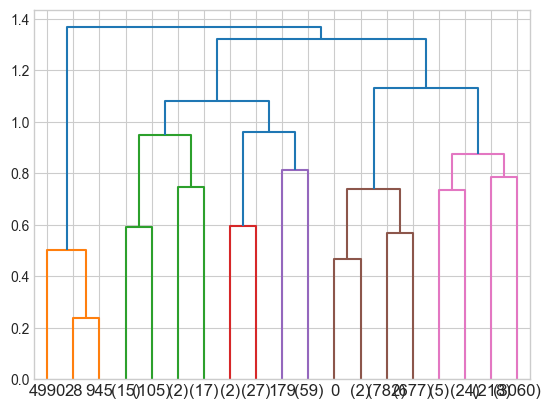

In [36]:
condensed_dist = squareform(average_kernel_dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4
)

In [37]:
model_hier_avg = AgglomerativeClustering(metric='precomputed', n_clusters=7, linkage='complete')
labels_hier_avg = model_hier_avg.fit_predict(average_kernel_dist_matrix)
print(np.unique(labels_hier_avg, return_counts=True))
df = df.with_columns(labels_hier_avg=labels_hier_avg)

(array([0, 1, 2, 3, 4, 5, 6]), array([3307,   60,   19,    3, 1462,   29,  120]))


In [20]:
create_chemiscope_viewer(df, average_kernel_dist_matrix, labels_hier_avg, projection_method)

2026-05-09 12:05:23.286 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running MDS dimensionality reduction...
2026-05-09 12:05:23.287 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-09 12:12:24.719 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


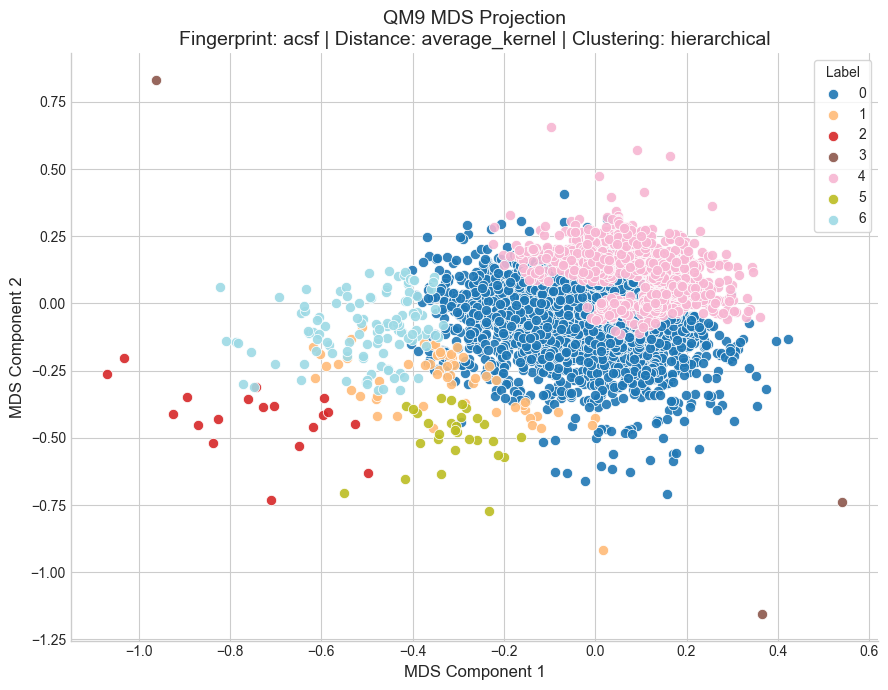

2026-05-09 14:14:59.474 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/average_kernel/acsf/mds_hierarchical_projection.png


{'coords': array([[-0.09747391,  0.65692093],
        [-0.2778391 ,  0.2591858 ],
        [-0.64408681, -0.03696168],
        ...,
        [-0.29615708,  0.24624896],
        [ 0.02539649,  0.31491695],
        [-0.14389133, -0.12810369]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/average_kernel/acsf/mds_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/average_kernel/acsf'),
 'clustering_method': 'hierarchical'}

In [38]:
plot_distance_matrix_projection(
    dist_matrix=average_kernel_dist_matrix,
    fingerprint="acsf",
    distance_metric="average_kernel",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hier_avg,
    clustering_method="hierarchical"
)

# ReMatch Kernel

In [39]:
rematch_kernel_dist_matrix = qm9.get_distance_matrix(descriptor="acsf_matrix", dist_type="rematch_kernel")

2026-05-09 14:14:59.651 | INFO     | src.datasets:get_distance_matrix:1313 - Calculating distance matrix for acsf_matrix using rematch_kernel distance.


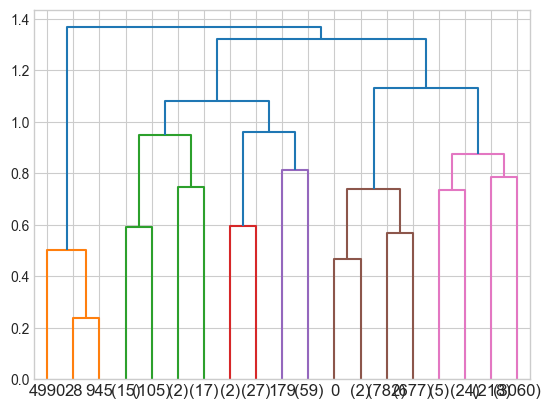

In [40]:
condensed_dist = squareform(rematch_kernel_dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4                 
)

In [24]:
model_hier_rematch = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier_rematch = model_hier_rematch.fit_predict(rematch_kernel_dist_matrix)
print(np.unique(labels_hier_rematch, return_counts=True))
df = df.with_columns(labels_hier_rematch=labels_hier_rematch)

(array([0, 1, 2, 3]), array([ 647,   49, 4296,    8]))


In [25]:
create_chemiscope_viewer(df, rematch_kernel_dist_matrix, labels_hier_rematch, projection_method)

2026-05-09 12:37:52.499 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running MDS dimensionality reduction...
2026-05-09 12:37:52.500 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-09 12:44:58.276 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


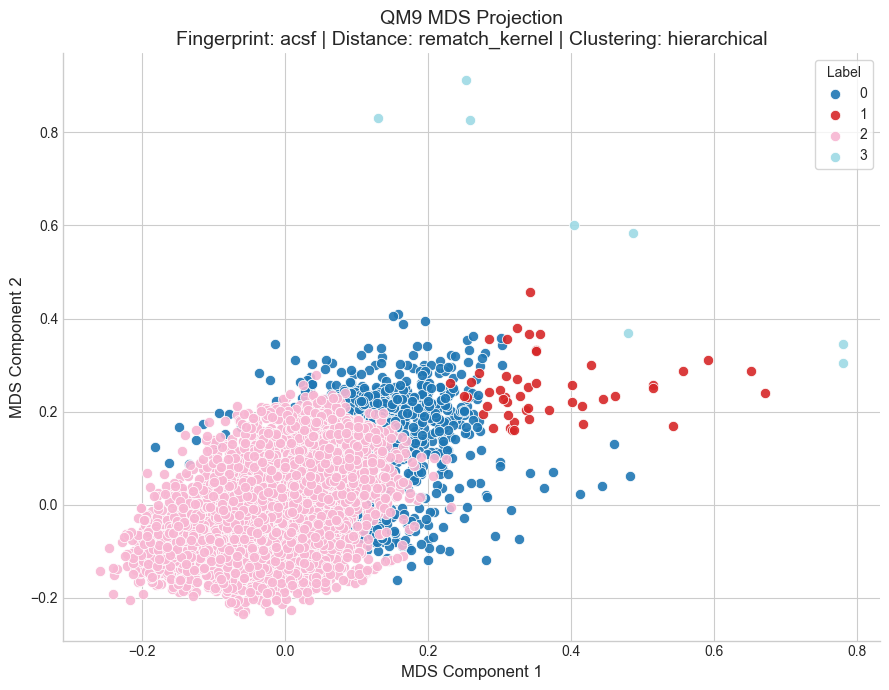

2026-05-09 13:19:27.813 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/rematch_kernel/acsf/mds_hierarchical_projection.png


In [34]:
_=plot_distance_matrix_projection(
    dist_matrix=rematch_kernel_dist_matrix,
    fingerprint="acsf",
    distance_metric="rematch_kernel",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hier_rematch,
    clustering_method="hierarchical"
)

# Spectral

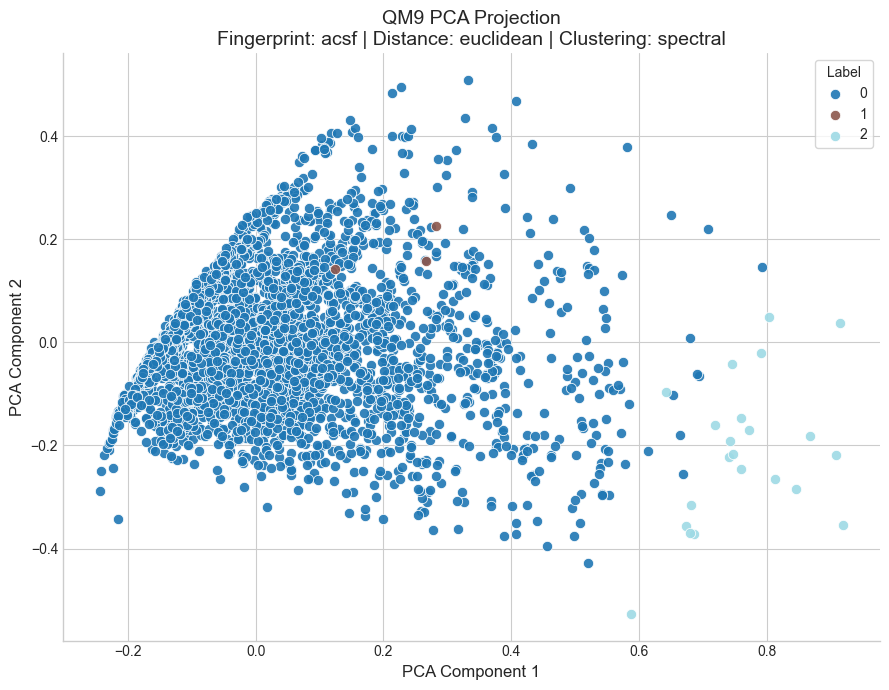

2026-05-12 10:53:21.605 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_spectral_projection.png


In [51]:
_=plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method='PCA',
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [28]:
_=average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬──────────┬─────────┬─────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

# DBSCAN 

In [29]:
model_db = DBSCAN(
    eps=0.6,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([0]), array([5000]))


In [30]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-05-09 12:50:54.619 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-09 12:50:54.620 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-09 12:51:52.183 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-09 12:51:52.197 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-09 12:51:52.606 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-09 12:51:52.726 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [31]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
average_numeric_by_cluster(df, "labels_db")

shape: (1, 74)
┌───────────┬───────┬────────────────┬─────────────┬────────────┬────────┬─────────┬────────────────┬────────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,5000,0.760148,0.0,122.6168,0.0604,35.746,0.878851,12.832857,8.7732,1.6982,0.1102,0.0048,2.3446,18.492,2.064709,2.299,0.068315,0.199532,0.732154,0.9348,1.9498,6.5532,0.4484,1.1682,4.812,6.3414,13.805,1.262932,0.0016,0.3818,0.0232,0.1276,0.1362,0.0014,0.041,0.1332,0.5398,0.0002,2.664332,75.369288,-6.539394,0.372169,6.911567,1188.560962,4.113629,-11123.988611,-11123.756272,-11123.730579,-11124.899361,31.859624,-76.781506,-77.250857,-77.693094,-71.45718,3.376555,1.399274,1.126404,0.0656,0.6454,0.005,78.9,10.76,10.34,13.805,1478,"""Acyclic""",10.34,342,"""C1CCCC1""",10.8,1,null,0.0


In [53]:
from src.helper_functions import evaluate_hdbscan_grid
import hdbscan
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=220, ms=1, clusters=3, noise=0.31, persistence=0.144, score=0.100
mcs=300, ms=1, clusters=3, noise=0.31, persistence=0.142, score=0.098
mcs=120, ms=1, clusters=6, noise=0.40, persistence=0.123, score=0.074
mcs=60, ms=1, clusters=17, noise=0.45, persistence=0.128, score=0.070
mcs=40, ms=1, clusters=26, noise=0.37, persistence=0.097, score=0.062
mcs=220, ms=10, clusters=2, noise=0.36, persistence=0.085, score=0.055
mcs=150, ms=1, clusters=6, noise=0.40, persistence=0.088, score=0.053
mcs=120, ms=10, clusters=2, noise=0.36, persistence=0.077, score=0.049
mcs=150, ms=10, clusters=2, noise=0.36, persistence=0.073, score=0.047


In [54]:
clusterer = hdbscan.HDBSCAN(
        min_cluster_size=220,
        min_samples=1,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-05-07 19:06:51.566 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 19:06:51.566 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 19:07:40.809 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 19:07:40.817 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 19:07:41.278 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 19:07:41.345 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

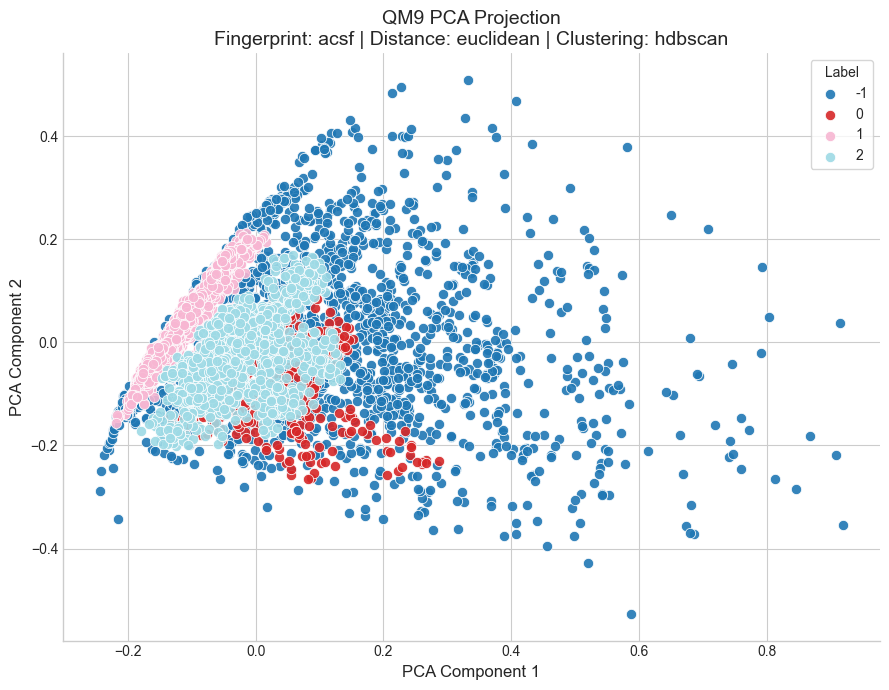

2026-05-12 10:57:50.482 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_hdbscan_projection.png


In [55]:
_=plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method='PCA',
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

In [ ]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (50, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,1621,0.766963,0.0,119.481801,0.022209,41.634176,0.843669,12.857188,8.552128,1.160395,0.228871,0.014806,2.668106,16.980259,2.014958,2.449722,0.124029,0.283723,0.592248,0.906231,2.231956,5.693399,0.797039,1.506477,3.580506,6.53979,12.708822,1.256967,0.003701,0.306601,0.048118,0.19926,0.142505,0.003701,0.051203,0.133868,0.548427,0.000617,2.904489,72.605065,-6.605338,-0.009956,6.595402,1223.097945,3.662893,-11064.219575,-11063.985952,-11063.960274,-11065.140033,30.984408,-71.325131,-71.735605,-72.139423,-66.462999,4.00125,1.378613,1.092102,0.186305,0.531154,0.015423,0.0,54.349167,22.208513,23.44232,12.708822,441,"""Acyclic""",23.44232,120,"""Acyclic""",23.44232,1,null,0.0
0,31,0.954762,0.0,126.516129,-0.290323,63.064516,0.916055,12.844579,8.967742,1.322581,0.322581,0.0,3.967742,14.129032,2.039708,1.580645,0.096774,0.458065,0.445161,0.935484,3.548387,4.967742,0.483871,2.290323,2.225806,5.967742,13.483871,1.27862,0.0,0.387097,0.16129,0.129032,0.290323,0.0,0.225806,0.096774,0.935484,0.0,3.34019,64.778387,-6.984285,-1.001993,5.981589,1118.178585,2.705555,-12790.757655,-12790.541362,-12790.515562,-12791.659463,28.552645,-62.964586,-63.284218,-63.615798,-58.839892,3.284434,1.380592,1.054586,0.0,0.0,0.0,0.0,61.290323,32.258065,6.451613,13.483871,27,"""c1cocn1""",6.451613,19,"""C1CCCC1""",19.354839,1,null,0.0
1,30,0.795349,0.0,124.666667,-0.533333,64.633333,0.556054,13.081076,8.9,1.266667,0.5,0.0,4.0,16.766667,2.030766,2.0,0.02,0.581667,0.398333,2.1,2.766667,6.833333,0.1,2.833333,1.966667,6.4,13.266667,1.252631,0.0,0.1,0.1,0.633333,0.333333,0.0,0.0,0.033333,0.066667,0.0,3.294113,74.500666,-6.032492,-0.681373,5.351482,1145.452238,3.348273,-11705.446354,-11705.22679,-11705.20127,-11706.341243,29.8369,-68.029084,-68.414795,-68.792582,-63.378998,3.26363,1.461818,1.013195,0.0,0.0,0.0,0.0,46.666667,50.0,3.333333,13.266667,25,"""c1cc[nH]c1""",10.0,12,"""C1CCCC1""",40.0,1,null,0.0
2,45,0.875372,0.0,125.666667,-0.577778,62.0,0.711606,12.971125,8.955556,1.377778,0.2,0.0,3.977778,15.422222,2.040329,1.355556,0.076667,0.46,0.463333,1.377778,2.866667,6.0,0.377778,2.288889,2.311111,5.977778,13.444444,1.269793,0.0,0.111111,0.044444,0.4,0.733333,0.0,0.133333,0.044444,0.422222,0.0,3.724769,69.062222,-6.669208,-0.773106,5.896042,1101.048444,3.048704,-12233.588542,-12233.372461,-12233.346636,-12234.488064,29.018867,-65.792598,-66.149461,-66.505817,-61.38514,3.043867,1.45335,1.087888,0.0,0.0,0.0,0.0,68.888889,20.0,11.111111,13.444444,38,"""Acyclic""",11.111111,24,"""C1CCCC1""",17.777778,1,null,0.0
3,37,1.001782,0.0,121.864865,0.027027,38.513514,1.006997,12.590751,8.945946,2.135135,0.054054,0.0,2.459459,14.540541,2.140283,0.702703,0.189189,0.271042,0.539768,0.27027,2.378378,5.27027,1.243243,1.72973,3.513514,5.837838,14.567568,1.291146,0.027027,0.243243,0.0,0.027027,0.027027,0.0,0.243

# KMeans

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
X = np.array(df['acsf_embedding'].to_list())
labels_kmeans = kmeans.fit_predict(X)
df = df.with_columns(labels_kmeans=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))


(array([0, 1, 2], dtype=int32), array([1587,  726, 2687]))


In [ ]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

2026-05-07 19:11:39.247 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 19:11:39.247 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 19:12:27.211 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 19:12:27.225 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 19:12:27.495 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 19:12:27.568 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [ ]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1587,0.85758,0.0,121.830498,-0.046629,35.426591,0.954437,12.731548,8.803403,2.10586,0.101449,0.011972,2.371141,16.63201,2.110146,1.42155,0.104168,0.232624,0.663208,0.722117,2.098299,6.081285,0.698173,1.436673,4.297417,6.068683,14.164461,1.27655,0.004411,0.3661,0.026465,0.064272,0.088847,0.0,0.079395,0.226213,…,2.736701,72.331934,-6.607766,-0.130654,6.477088,1093.457548,3.536585,-11327.659583,-11327.445133,-11327.419452,-11328.549463,29.675365,-71.613828,-72.031504,-72.427313,-66.789272,3.44605,1.504782,1.215524,0.167612,0.175173,0.0,0.0,16.491493,83.868935,10.018904,6.112161,14.164461,714,"""Acyclic""",6.112161,258,"""C1CCCC1""",8.065532,1,null,0.0
1,726,0.825458,0.0,121.104683,-0.402204,55.995868,0.622429,12.999138,8.706612,1.381543,0.451791,0.006887,3.527548,16.190083,2.038581,1.742424,0.082422,0.459216,0.458363,1.545455,2.615702,6.219008,0.451791,2.263085,2.464187,6.260331,13.179063,1.258625,0.001377,0.104683,0.090909,0.450413,0.297521,0.004132,0.015152,0.057851,…,3.363918,71.772534,-6.277078,-0.300255,5.976868,1106.71578,3.341083,-11315.394375,-11315.177154,-11315.151442,-11316.288859,29.363231,-67.63512,-68.02014,-68.396049,-63.03265,3.693963,1.496619,1.117986,0.085399,0.360882,0.034435,0.0,4.946281,47.245179,43.663912,9.090909,13.179063,334,"""Acyclic""",9.090909,94,"""C1CCCC1""",26.997245,1,null,0.0
2,2687,0.684956,0.0,123.489766,0.248604,30.463342,0.90349,12.847765,8.773353,1.542985,0.023074,0.0,2.009304,20.212505,2.044932,2.967622,0.043328,0.109822,0.84685,0.895422,1.682173,6.922218,0.299963,0.713807,5.750279,6.524377,13.761816,1.256052,0.0,0.465947,0.002977,0.077782,0.120581,0.001489,0.025307,0.098623,…,2.432568,78.13502,-6.569887,0.850829,7.420726,1266.844817,4.663177,-10951.980268,-10951.733278,-10951.707584,-10952.90774,33.824194,-82.304908,-82.827564,-83.315143,-76.490369,3.249749,1.310657,1.076042,0.0,1.0,0.0,0.0,27.386677,84.51805,2.307406,13.174544,13.761816,722,"""Acyclic""",13.174544,190,"""C1CC1""",13.844436,1,null,0.0


# Average Kernel

2026-05-12 17:25:58.837 | INFO     | src.datasets:get_distance_matrix:1313 - Calculating distance matrix for acsf_matrix using average_kernel distance.


(array([0, 1, 2, 3]), array([ 228, 1462, 3307,    3]))


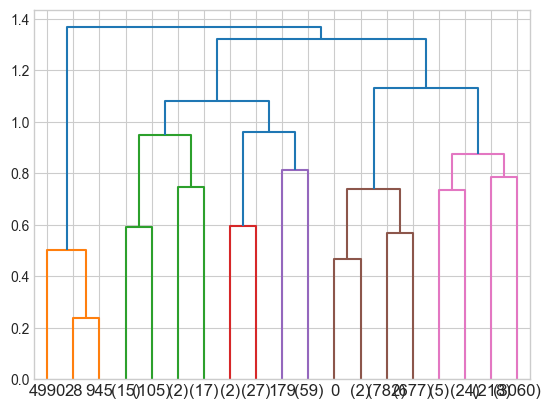

In [58]:
# Average Kernel
average_kernel_dist_matrix = qm9.get_distance_matrix(descriptor="acsf_matrix", dist_type="average_kernel")
condensed_dist = squareform(average_kernel_dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4,
)
model_hier_avg = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier_avg = model_hier_avg.fit_predict(average_kernel_dist_matrix)
print(np.unique(labels_hier_avg, return_counts=True))
df = df.with_columns(labels_hier_avg=labels_hier_avg)

In [ ]:
create_chemiscope_viewer(df, average_kernel_dist_matrix, labels_hier_avg, projection_method)

In [ ]:
_=plot_distance_matrix_projection(
    dist_matrix=average_kernel_dist_matrix,
    fingerprint="acsf",
    distance_metric="average_kernel",
    projection_method='MDS',
    dataset_name="qm9",
    labels=labels_hier_avg,
    clustering_method="hierarchical"
)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


# Rematch kernel

2026-05-12 17:39:28.282 | INFO     | src.datasets:get_distance_matrix:1313 - Calculating distance matrix for acsf_matrix using rematch_kernel distance.


(array([0, 1, 2, 3]), array([ 228, 1462, 3307,    3]))


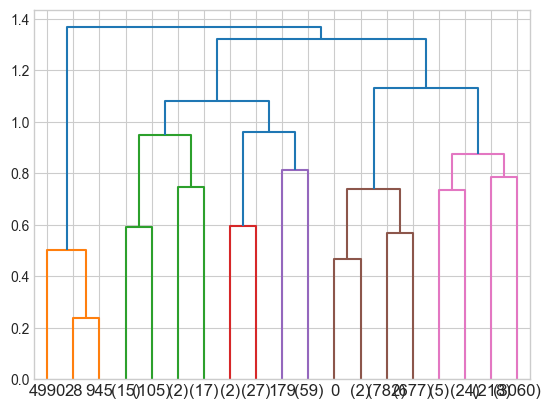

In [59]:
# ReMatch Kernel
rematch_kernel_dist_matrix = qm9.get_distance_matrix(descriptor="acsf_matrix", dist_type="rematch_kernel")
condensed_dist = squareform(rematch_kernel_dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4                 
)
model_hier_rematch = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier_rematch = model_hier_rematch.fit_predict(rematch_kernel_dist_matrix)
print(np.unique(labels_hier_rematch, return_counts=True))
df = df.with_columns(labels_hier_rematch=labels_hier_rematch)

In [ ]:
create_chemiscope_viewer(df, rematch_kernel_dist_matrix, labels_hier_rematch, projection_method)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


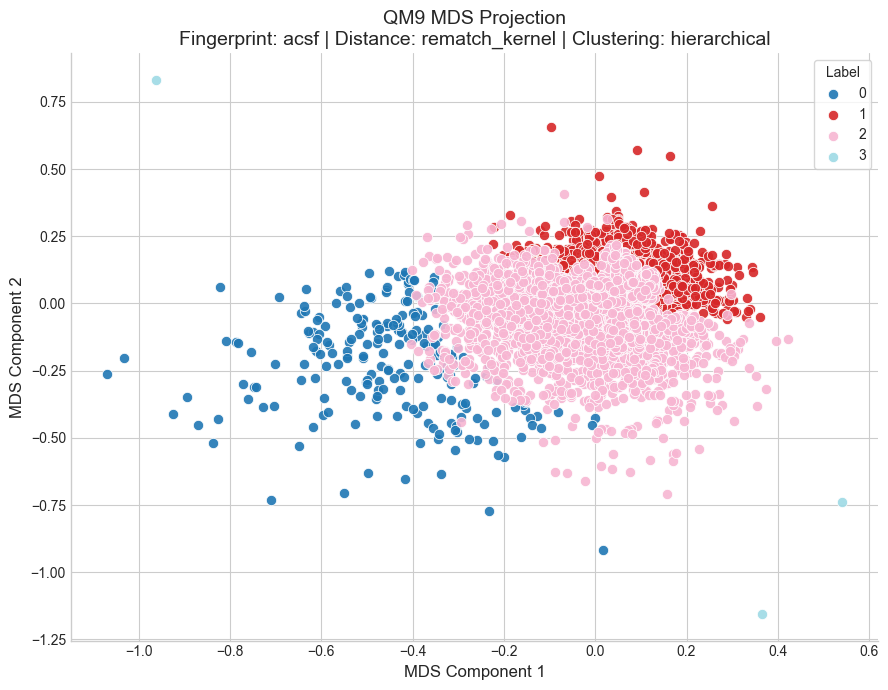

2026-05-12 20:44:21.512 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/rematch_kernel/acsf/mds_hierarchical_projection.png


In [60]:
_=plot_distance_matrix_projection(
    dist_matrix=rematch_kernel_dist_matrix,
    fingerprint="acsf",
    distance_metric="rematch_kernel",
    projection_method='MDS',
    dataset_name="qm9",
    labels=labels_hier_rematch,
    clustering_method="hierarchical"
)